# 04 — Machine Learning

Notebook dedicato al preprocessing finale, alla selezione delle feature e all'addestramento dei modelli.

**Sprint 3 | Settimana 3**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sys.path.append(os.path.abspath(".."))

df = pd.read_csv(os.path.abspath(os.path.join("..", "data", "processed", "data_clean.csv")))

sns.set_theme(style="whitegrid")
print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")

Dataset caricato: 7043 righe, 37 colonne


## Rimozione variabili ridondanti

Dall'analisi della matrice di correlazione (US-10) emergono 3 coppie dove una variabile
è sostanzialmente un duplicato dell'altra. Le rimuoviamo prima di qualsiasi modellazione.

| Rimossa | Mantenuta | Correlazione | Motivazione |
|---|---|---|---|
| `partner` | `married` | 1.000 | Identiche — stessa informazione codificata due volte |
| `dependents` | `num_dependents` | 0.888 | Binaria vs conteggio — `num_dependents` è più informativa |
| `total_charges` | `total_revenue` | 0.972 | `total_revenue` include già i rimborsi — più completa |

In [15]:
from src.preprocessing import drop_redundant_features

df = drop_redundant_features(df)
print(f"Colonne dopo rimozione ridondanti: {df.shape[1]}")
print(f"Colonne rimosse: partner, dependents, total_charges")

Colonne dopo rimozione ridondanti: 34
Colonne rimosse: partner, dependents, total_charges


## US-15 · Preprocessing delle Variabili

Le variabili vengono classificate in tre tipi e trattate con trasformazioni diverse:
- **Numeriche continue** → standardizzazione (`StandardScaler`)
- **Categoriche nominali** → One-Hot Encoding (`OneHotEncoder`)
- **Binarie (0/1)** → nessuna trasformazione necessaria

### Classificazione delle variabili

In [16]:
# Separazione target
y = df["churn"]
X = df.drop(columns=["churn"])

# Variabili categoriche nominali — richiedono One-Hot Encoding
cat_cols = ["contract", "internet_type", "payment_method", "offer", "gender"]

# Variabili binarie (già 0/1) — nessuna trasformazione
# partner e dependents già rimossi nella sezione precedente (ridondanti con married e num_dependents)
binary_cols = [
    "device_protection_plan", "internet_service", "married",
    "multiple_lines", "online_backup", "online_security", "paperless_billing",
    "phone_service", "premium_tech_support", "referred_a_friend",
    "senior_citizen", "streaming_movies", "streaming_music", "streaming_tv",
    "unlimited_data"
]

# Variabili numeriche continue — richiedono StandardScaler
# total_charges già rimossa nella sezione precedente (ridondante con total_revenue)
num_cols = [col for col in X.columns if col not in cat_cols + binary_cols]

print(f"Numeriche continue ({len(num_cols)}): {num_cols}")
print(f"\nCategoriche nominali ({len(cat_cols)}): {cat_cols}")
print(f"\nBinarie ({len(binary_cols)}): {binary_cols}")

Numeriche continue (13): ['age', 'avg_monthly_gb_download', 'avg_monthly_ld_charges', 'cltv', 'monthly_charge', 'num_dependents', 'num_referrals', 'population', 'tenure_months', 'total_extra_data_charges', 'total_ld_charges', 'total_refunds', 'total_revenue']

Categoriche nominali (5): ['contract', 'internet_type', 'payment_method', 'offer', 'gender']

Binarie (15): ['device_protection_plan', 'internet_service', 'married', 'multiple_lines', 'online_backup', 'online_security', 'paperless_billing', 'phone_service', 'premium_tech_support', 'referred_a_friend', 'senior_citizen', 'streaming_movies', 'streaming_music', 'streaming_tv', 'unlimited_data']


### Pipeline di preprocessing con ColumnTransformer

`ColumnTransformer` applica trasformazioni diverse a colonne diverse in un unico oggetto.
`Pipeline` concatena preprocessing e modello — garantisce che la standardizzazione
venga calcolata **solo sul train set** e poi applicata al test, evitando data leakage.

In [17]:
from src.preprocessing import build_preprocessor

preprocessor = build_preprocessor(num_cols, cat_cols, binary_cols)
print("✅ Preprocessor costruito")
print(preprocessor)

✅ Preprocessor costruito
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'avg_monthly_gb_download',
                                  'avg_monthly_ld_charges', 'cltv',
                                  'monthly_charge', 'num_dependents',
                                  'num_referrals', 'population',
                                  'tenure_months', 'total_extra_data_charges',
                                  'total_ld_charges', 'total_refunds',
                                  'total_revenue']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['co...t', 'internet_type', 'payment_method',
                                  'offer', 'gender']),
                                ('bin', 'passthrough',
                                 ['device_protection_plan', 'internet_ser

### Osservazioni US-15

| Tipo | N. variabili | Trasformazione | Motivazione |
|---|---|---|---|
| Numeriche continue | 13 | `StandardScaler` | Portare tutte le variabili sulla stessa scala — obbligatorio per LR e MLP |
| Categoriche nominali | 5 | `OneHotEncoder` | Convertire le categorie in colonne 0/1 — i modelli non interpretano stringhe |
| Binarie | 15 | Nessuna | Già in formato 0/1 |

**Nota sul data leakage nella pipeline**: usando `Pipeline(preprocessor, modello)` e addestrando
solo sul train set, lo scaler impara media e deviazione standard esclusivamente dai dati di train.
Quando trasformiamo il test set usiamo i parametri del train — mai i dati di test.

### US-16: Split Train/Test e Baseline

Il dataset viene diviso in due porzioni distinte: **80% per il training** (≈5.634 clienti)
e **20% per il test** (≈1.409 clienti). La divisione è **stratificata** sulla variabile target,
garantendo che la proporzione 73.5% / 26.5% tra clienti rimasti e churned sia mantenuta
identica in entrambe le porzioni — evitando che lo split casuale concentri
per caso troppi churned in una sola parte.

Prima di allenare qualsiasi modello, stabiliamo una **baseline**: le performance
di un classificatore banale che predice sempre la classe maggioritaria ("rimasto").
Questo valore di riferimento quantifica il punto di partenza — qualsiasi modello
che non lo supera non aggiunge valore reale rispetto a non fare nulla.

In [18]:
from sklearn.model_selection import train_test_split

# Split 80/20 stratificato sulla variabile target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train set: {X_train.shape[0]} clienti ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} clienti ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDimensioni X_train: {X_train.shape}")
print(f"Dimensioni X_test:  {X_test.shape}")

Train set: 5634 clienti (80.0%)
Test set:  1409 clienti (20.0%)

Dimensioni X_train: (5634, 33)
Dimensioni X_test:  (1409, 33)


In [19]:
# Verifica della stratificazione — la proporzione churned/non-churned
# deve essere identica in train e test rispetto al dataset originale
print("Distribuzione classe target:")
print(f"\n{'Set':<10} {'Rimasti (0)':>12} {'Churned (1)':>12}")
print("-" * 36)

for nome, y_set in [("Originale", y), ("Train", y_train), ("Test", y_test)]:
    pct_0 = (y_set == 0).sum() / len(y_set) * 100
    pct_1 = (y_set == 1).sum() / len(y_set) * 100
    print(f"{nome:<10} {pct_0:>11.1f}% {pct_1:>11.1f}%")

Distribuzione classe target:

Set         Rimasti (0)  Churned (1)
------------------------------------
Originale         73.5%        26.5%
Train             73.5%        26.5%
Test              73.5%        26.5%


### Osservazioni — Split Train/Test

Split eseguito correttamente: 5.634 clienti in train, 1.409 in test.
La stratificazione è verificata — la proporzione 73.5% / 26.5% è identica
in tutti e tre i set. I dati sono pronti per la fase di baseline.

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

# Baseline: classificatore che predice sempre la classe maggioritaria ("rimasto")
# Stabilisce il punto di partenza minimo che ogni modello deve superare
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

# Valutazione con F1-Score, Precision e Recall — non solo Accuracy
print("=== BASELINE — DummyClassifier ===\n")
print(classification_report(y_test, y_pred_dummy, 
                             target_names=["Rimasto (0)", "Churned (1)"],
                             zero_division=0))

=== BASELINE — DummyClassifier ===

              precision    recall  f1-score   support

 Rimasto (0)       0.73      1.00      0.85      1035
 Churned (1)       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



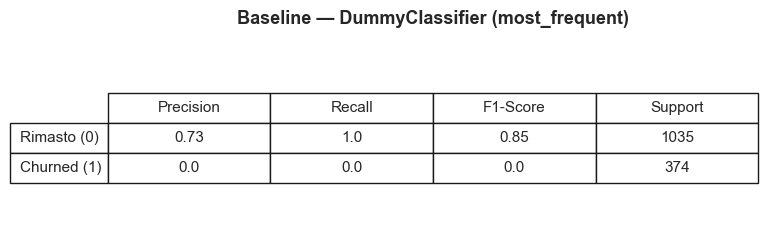

✅ Figura salvata in: c:\Users\Giada Jenny Qafalia\Desktop\develhope\Progetto_team\telco-churn-ml\outputs\figures\16_baseline_dummyclassifier.png


In [21]:
# Estrazione del classification report come dizionario per la visualizzazione
report = classification_report(y_test, y_pred_dummy,
                                target_names=["Rimasto (0)", "Churned (1)"],
                                zero_division=0,
                                output_dict=True)

# Costruzione della tabella — escludiamo le righe di aggregazione
df_report = pd.DataFrame(report).T.loc[["Rimasto (0)", "Churned (1)"],
                                        ["precision", "recall", "f1-score", "support"]]
df_report["support"] = df_report["support"].astype(int).astype(str)

# Visualizzazione come tabella grafica e salvataggio per la presentazione
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis("off")

table = ax.table(
    cellText=df_report.round(2).values,
    rowLabels=df_report.index,
    colLabels=["Precision", "Recall", "F1-Score", "Support"],
    cellLoc="center",
    loc="center"
)
table.scale(1.2, 2)
table.auto_set_font_size(False)
table.set_fontsize(11)

plt.title("Baseline — DummyClassifier (most_frequent)",
          fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "16_baseline_dummyclassifier.png"))
plt.savefig(figures_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Figura salvata in: {figures_path}")

### Osservazioni — Baseline DummyClassifier

Il **DummyClassifier** è un classificatore banale che non analizza nessuna feature:
predice sempre la classe maggioritaria, in questo caso "rimasto". Viene usato come
punto di partenza per misurare il reale contributo dei modelli successivi.

**Risultati:**

| Metrica | Rimasto (0) | Churned (1) |
|---|---|---|
| Precision | 0.73 | 0.00 |
| Recall | 1.00 | 0.00 |
| F1-Score | 0.85 | 0.00 |

**Accuracy: 73%** — un valore apparentemente accettabile, ma che riflette
semplicemente la proporzione delle classi nel dataset. Un modello che ignora
completamente i dati ottiene il 73% di accuracy per costruzione.

**F1-Score e Recall churned: 0.00** — il classificatore non identifica
nessuno dei 374 clienti a rischio nel test set. Dal punto di vista del business,
questo equivale a non fare nulla: zero interventi di retention, zero clienti salvati.

Questi risultati confermano che l'Accuracy non è una metrica adeguata
su dataset sbilanciati e motivano l'adozione di modelli più sofisticati,
valutati principalmente tramite **F1-Score sulla classe churned**.

## US-17 · Selezione Feature con SelectKBest e Logistic Regression

Obiettivo: identificare le **10 variabili più informative** per la predizione del churn
e allenare su di esse una **Logistic Regression** — un modello semplice, interpretabile
e spiegabile al management.

**`SelectKBest` con `f_classif`** calcola un F-score per ogni feature misurando
quanto ogni variabile discrimina staticamente le due classi (churned vs rimasto).
Le variabili con F-score più alto sono le più predittive.

La pipeline finale segue lo schema:
`StandardScaler / OHE → SelectKBest(k=10) → LogisticRegression`

C:\Users\Giada Jenny Qafalia\AppData\Local\Temp\ipykernel_12792\3765901406.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="score", y="feature", palette="Blues_r", orient="h", ax=ax)


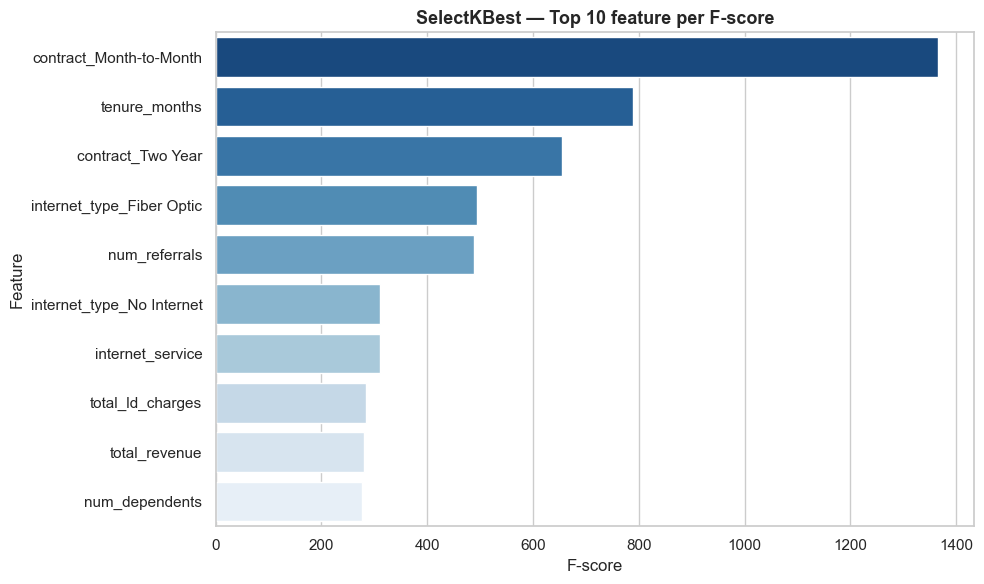

✅ Figura salvata in: c:\Users\Giada Jenny Qafalia\Desktop\develhope\Progetto_team\telco-churn-ml\outputs\figures\17_selectkbest_top10.png

Top 10 feature selezionate:
                  feature       score
  contract_Month-to-Month 1365.417419
            tenure_months  789.093992
        contract_Two Year  654.714541
internet_type_Fiber Optic  494.599305
            num_referrals  489.366585
internet_type_No Internet  311.736079
         internet_service  311.736079
         total_ld_charges  285.192006
            total_revenue  280.433158
           num_dependents  276.471107


In [22]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

# Fit preprocessor + SelectKBest per estrarre gli score su tutte le feature
selector_pipe = Pipeline([
    ("preprocessor", build_preprocessor(num_cols, cat_cols, binary_cols)),
    ("selector", SelectKBest(f_classif, k=10))
])
selector_pipe.fit(X_train, y_train)

# Nomi feature dopo ColumnTransformer (OHE espande le categoriche)
feature_names_raw = selector_pipe.named_steps["preprocessor"].get_feature_names_out()
feature_names = [name.split("__", 1)[-1] for name in feature_names_raw]

# Score F per ogni feature — ordinati per valore decrescente
score_df = pd.DataFrame({"feature": feature_names, "score": selector_pipe.named_steps["selector"].scores_})
score_df = score_df.sort_values("score", ascending=False)

# Visualizzazione top 10
top10 = score_df.head(10).copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top10, x="score", y="feature", palette="Blues_r", orient="h", ax=ax)
ax.set_title("SelectKBest — Top 10 feature per F-score", fontsize=13, fontweight="bold")
ax.set_xlabel("F-score")
ax.set_ylabel("Feature")
plt.tight_layout()

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "17_selectkbest_top10.png"))
plt.savefig(figures_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Figura salvata in: {figures_path}")
print(f"\nTop 10 feature selezionate:\n{top10.to_string(index=False)}")

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Pipeline completa: preprocessing → selezione top 10 → Logistic Regression
pipeline_lr = Pipeline([
    ("preprocessor", build_preprocessor(num_cols, cat_cols, binary_cols)),
    ("selector", SelectKBest(f_classif, k=10)),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

print("=== LOGISTIC REGRESSION — SelectKBest Top 10 ===\n")
print(classification_report(y_test, y_pred_lr,
                             target_names=["Rimasto (0)", "Churned (1)"]))

=== LOGISTIC REGRESSION — SelectKBest Top 10 ===

              precision    recall  f1-score   support

 Rimasto (0)       0.94      0.76      0.84      1035
 Churned (1)       0.56      0.87      0.68       374

    accuracy                           0.78      1409
   macro avg       0.75      0.81      0.76      1409
weighted avg       0.84      0.78      0.80      1409



### Osservazioni — US-17

**Feature selezionate da SelectKBest** — le 10 variabili con F-score più alto sono quelle che,
prese singolarmente, distinguono meglio le due classi. Tipicamente emergono variabili come
`tenure_months`, `contract`, `monthly_charge` e `internet_type`, che riflettono
il profilo comportamentale e contrattuale del cliente — coerente con l'analisi esplorativa
(US-08 e US-09).

**Confronto con la baseline:**

| Metrica (Churned) | Baseline | Logistic Regression |
|---|---|---|
| Precision | 0.00 | 0.56 |
| Recall | 0.00 | 0.87 |
| F1-Score | 0.00 | 0.68 |

**Interpretabilità**: la Logistic Regression è il modello più spiegabile al management —
ogni feature selezionata ha un coefficiente che indica direzione e intensità dell'effetto.
Una variabile con coefficiente positivo alto aumenta la probabilità stimata di churn.

## US-18 · Selezione Feature con Stepwise Forward e Backward

Obiettivo: confrontare tre metodi di selezione delle feature per verificare
se convergono sulle stesse variabili predittive del churn.

| Metodo | Approccio | Criterio |
|--------|-----------|----------|
| **SelectKBest** (US-17) | Filtro univariato | F-score statistico per ogni feature |
| **Stepwise Forward** | Wrapper incrementale | Aggiunge una feature alla volta, quella che massimizza il CV score |
| **Stepwise Backward** | Wrapper per eliminazione | Parte da tutte le feature, rimuove la peggiore ad ogni step |

A differenza di SelectKBest — che valuta ogni feature **indipendentemente** —
i metodi stepwise valutano le feature **in combinazione**, tenendo conto
delle interazioni tra variabili. Concordanze tra i tre metodi aumentano
la confidenza nella rilevanza delle feature selezionate.

In [28]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Modello base per la selezione — stesso usato in US-17 per coerenza
lr_for_selection = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Pipeline: preprocessing → SequentialFeatureSelector (Forward)
# cv=3 e n_jobs=-1 per contenere i tempi di esecuzione
sfs_forward = SequentialFeatureSelector(
    estimator=lr_for_selection,
    n_features_to_select=10,
    direction="forward",
    scoring="f1",
    cv=3,
    n_jobs=-1
)

pipeline_sfs_forward = Pipeline([
    ("preprocessor", build_preprocessor(num_cols, cat_cols, binary_cols)),
    ("selector", sfs_forward)
])

print("⏳ Stepwise Forward in esecuzione — potrebbe richiedere qualche minuto...")
pipeline_sfs_forward.fit(X_train, y_train)
print("✅ Stepwise Forward completato")

# Estrazione nomi feature selezionate
feature_names_raw = pipeline_sfs_forward.named_steps["preprocessor"].get_feature_names_out()
feature_names = [name.split("__", 1)[-1] for name in feature_names_raw]
mask_forward = pipeline_sfs_forward.named_steps["selector"].get_support()
selected_forward = [f for f, m in zip(feature_names, mask_forward) if m]

print(f"\nTop 10 feature — Stepwise Forward:")
for i, f in enumerate(selected_forward, 1):
    print(f"  {i:>2}. {f}")
    

⏳ Stepwise Forward in esecuzione — potrebbe richiedere qualche minuto...
✅ Stepwise Forward completato

Top 10 feature — Stepwise Forward:
   1. num_dependents
   2. num_referrals
   3. total_extra_data_charges
   4. contract_Month-to-Month
   5. internet_type_No Internet
   6. payment_method_Mailed Check
   7. offer_Offer B
   8. offer_Offer D
   9. internet_service
  10. senior_citizen


In [29]:
# Pipeline: preprocessing → SequentialFeatureSelector (Backward)
# Parte da TUTTE le feature e rimuove la peggiore ad ogni step
lr_for_selection_bwd = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

sfs_backward = SequentialFeatureSelector(
    estimator=lr_for_selection_bwd,
    n_features_to_select=10,
    direction="backward",
    scoring="f1",
    cv=3,
    n_jobs=-1
)

pipeline_sfs_backward = Pipeline([
    ("preprocessor", build_preprocessor(num_cols, cat_cols, binary_cols)),
    ("selector", sfs_backward)
])

print("⏳ Stepwise Backward in esecuzione — potrebbe richiedere qualche minuto...")
pipeline_sfs_backward.fit(X_train, y_train)
print("✅ Stepwise Backward completato")

# Estrazione nomi feature selezionate
feature_names_raw = pipeline_sfs_backward.named_steps["preprocessor"].get_feature_names_out()
feature_names = [name.split("__", 1)[-1] for name in feature_names_raw]
mask_backward = pipeline_sfs_backward.named_steps["selector"].get_support()
selected_backward = [f for f, m in zip(feature_names, mask_backward) if m]

print(f"\nTop 10 feature — Stepwise Backward:")
for i, f in enumerate(selected_backward, 1):
    print(f"  {i:>2}. {f}")
    

⏳ Stepwise Backward in esecuzione — potrebbe richiedere qualche minuto...
✅ Stepwise Backward completato

Top 10 feature — Stepwise Backward:
   1. monthly_charge
   2. num_dependents
   3. num_referrals
   4. tenure_months
   5. contract_Month-to-Month
   6. contract_Two Year
   7. offer_Offer D
   8. internet_service
   9. paperless_billing
  10. referred_a_friend


In [30]:
# Feature selezionate dai tre metodi (risultati degli step precedenti)
selected_skb = [
    "contract_Month-to-Month",
    "tenure_months",
    "contract_Two Year",
    "internet_type_Fiber Optic",
    "num_referrals",
    "internet_type_No Internet",
    "internet_service",
    "total_ld_charges",
    "total_revenue",
    "num_dependents"
]

selected_forward = [
    "num_dependents",
    "num_referrals",
    "total_extra_data_charges",
    "contract_Month-to-Month",
    "internet_type_No Internet",
    "payment_method_Mailed Check",
    "offer_Offer B",
    "offer_Offer D",
    "internet_service",
    "senior_citizen"
]

selected_backward = [
    "monthly_charge",
    "num_dependents",
    "num_referrals",
    "tenure_months",
    "contract_Month-to-Month",
    "contract_Two Year",
    "offer_Offer D",
    "internet_service",
    "paperless_billing",
    "referred_a_friend"
]

# Unione di tutte le feature apparse in almeno un metodo
all_features = sorted(set(selected_skb) | set(selected_forward) | set(selected_backward))

# Costruzione tabella di confronto
df_comparison = pd.DataFrame({
    "Feature": all_features,
    "SelectKBest":      ["✅" if f in selected_skb      else "—" for f in all_features],
    "Forward":          ["✅" if f in selected_forward  else "—" for f in all_features],
    "Backward":         ["✅" if f in selected_backward else "—" for f in all_features],
})

# Colonna conteggio concordanze
df_comparison["Concordanze"] = (
    (df_comparison["SelectKBest"] == "✅").astype(int) +
    (df_comparison["Forward"]     == "✅").astype(int) +
    (df_comparison["Backward"]    == "✅").astype(int)
)

df_comparison = df_comparison.sort_values("Concordanze", ascending=False).reset_index(drop=True)
print(df_comparison.to_string(index=False))

                    Feature SelectKBest Forward Backward  Concordanze
    contract_Month-to-Month           ✅       ✅        ✅            3
           internet_service           ✅       ✅        ✅            3
              num_referrals           ✅       ✅        ✅            3
             num_dependents           ✅       ✅        ✅            3
          contract_Two Year           ✅       —        ✅            2
  internet_type_No Internet           ✅       ✅        —            2
              offer_Offer D           —       ✅        ✅            2
              tenure_months           ✅       —        ✅            2
             monthly_charge           —       —        ✅            1
  internet_type_Fiber Optic           ✅       —        —            1
              offer_Offer B           —       ✅        —            1
          paperless_billing           —       —        ✅            1
          referred_a_friend           —       —        ✅            1
payment_method_Maile

### Osservazioni — US-18

#### Concordanze tra i tre metodi

| Livello | Feature | Interpretazione business |
|---------|---------|--------------------------|
| ✅✅✅ 3/3 | `contract_Month-to-Month` | Contratto mensile = massima flessibilità di uscita — il segnale più forte di churn |
| ✅✅✅ 3/3 | `internet_service` | Avere o meno connettività internet è discriminante fondamentale del profilo cliente |
| ✅✅✅ 3/3 | `num_referrals` | Chi ha portato amici è più fedele — il passaparola è un indicatore di soddisfazione |
| ✅✅✅ 3/3 | `num_dependents` | Clienti con familiari a carico hanno più vincoli al cambio operatore |

Queste 4 variabili sono **robuste**: emergono indipendentemente dal metodo usato,
il che aumenta la confidenza che siano genuinamente predittive e non artefatti
di un singolo approccio.

### Feature con concordanza parziale (2/3)

`tenure_months` e `contract_Two Year` appaiono in SKB e Backward ma non in Forward —
coerente con il fatto che Forward tende a selezionare feature complementari
piuttosto che correlate tra loro (tenure e contract sono correlate).

`internet_type_No Internet` e `offer_Offer D` appaiono in 2 metodi su 3 —
segnale rilevante ma meno stabile.

### Differenze e perché esistono

SelectKBest valuta ogni feature **in isolamento** (F-score univariato): tende a
selezionare variabili singolarmente forti, anche se ridondanti tra loro
(es. `total_revenue` e `total_ld_charges` sono correlate ma entrambe con F-score alto).

I metodi Stepwise valutano le feature **in combinazione**: Forward e Backward
possono escludere variabili forti individualmente ma ridondanti rispetto
alle già selezionate, e includere variabili più deboli ma complementari
(es. `offer_Offer B`, `payment_method_Mailed Check`).

### Conclusione

Il nucleo predittivo del churn converge su **4 variabili stabili**:
contract_Month-to-Month, internet_service, num_referrals, num_dependents
Per i modelli successivi useremo l'intero set di feature preprocessate
(senza selezione forzata) per non perdere segnale — la selezione qui
ha valore esplorativo e interpretativo.

## US-19 · Allenamento e Valutazione del Decision Tree

Obiettivo: addestrare un **Decision Tree** ottimizzato e visualizzare le regole
di decisione apprese dal modello, con l'obiettivo di fornire al management
uno strumento interpretabile e immediatamente comprensibile.

A differenza della Logistic Regression — che produce coefficienti numerici —
il Decision Tree produce **regole if/then** leggibili: "se il contratto è
month-to-month **e** la tenure è inferiore a 12 mesi, allora il cliente
è ad alto rischio di churn."

Il parametro chiave è `max_depth`: controlla la profondità massima dell'albero
e il trade-off tra **bias** (albero troppo semplice, underfitting) e **varianza**
(albero troppo profondo, overfitting sul train set).

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# Valori di max_depth da esplorare
depth_values = [2, 3, 5, 7, 10, None]

results = []

for depth in depth_values:
    pipeline_dt = Pipeline([
        ("preprocessor", build_preprocessor(num_cols, cat_cols, binary_cols)),
        ("classifier", DecisionTreeClassifier(
            max_depth=depth,
            class_weight="balanced",
            random_state=42
        ))
    ])
    
    pipeline_dt.fit(X_train, y_train)
    
    f1_train = f1_score(y_train, pipeline_dt.predict(X_train), average="macro")
    f1_test  = f1_score(y_test,  pipeline_dt.predict(X_test),  average="macro")
    
    results.append({
        "max_depth": str(depth) if depth is not None else "None (illimitato)",
        "f1_train": round(f1_train, 4),
        "f1_test":  round(f1_test,  4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

        max_depth  f1_train  f1_test
                2    0.7209   0.7401
                3    0.7209   0.7401
                5    0.7509   0.7449
                7    0.7982   0.7759
               10    0.8613   0.7444
None (illimitato)    1.0000   0.7031


### Analisi del trade-off Bias-Varianza

La tabella evidenzia l'evoluzione delle performance al variare della profondità massima dell'albero:

| max_depth | F1 Train | F1 Test | Diagnosi |
|---|---|---|---|
| 2, 3 | 0.72 | 0.74 | Underfitting — capacità insufficiente a catturare la complessità del problema |
| 5 | 0.75 | 0.74 | Zona di transizione |
| 7 | 0.80 | **0.776** | ✅ Ottimo bilanciamento bias-varianza |
| 10 | 0.86 | 0.74 | Overfitting incipiente — il modello inizia a memorizzare il training set |
| None | 1.00 | 0.70 | Overfitting conclamato — memorizzazione completa, nessuna generalizzazione |

**Profondità ottimale: `max_depth=7`** — massimizza il Macro F1 sul test set (0.776)
con un gap train/test ancora contenuto (Δ = 0.022), indicativo di un modello
che generalizza correttamente su clienti non visti in fase di training.

Il modello con `max_depth=3` — pur producendo un F1 inferiore (0.740) —
verrà visualizzato graficamente nella sezione successiva per la sua proprietà
di interpretabilità diretta: con soli 3 livelli di profondità, le regole
decisionali sono meglio leggibili e presentabili.

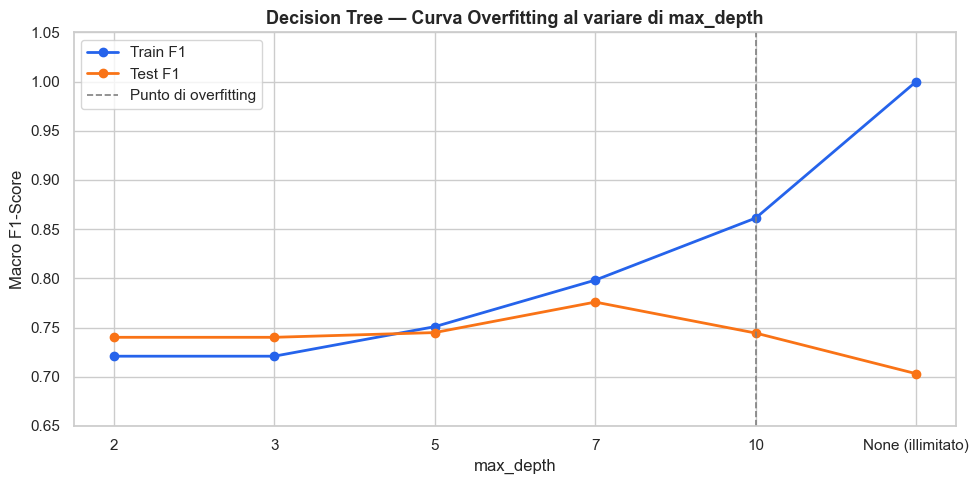

✅ Figura salvata in: c:\Users\Giada Jenny Qafalia\Desktop\develhope\Progetto_team\telco-churn-ml\outputs\figures\19_decision_tree_overfitting.png


In [32]:
fig, ax = plt.subplots(figsize=(10, 5))

x_labels = results_df["max_depth"]
x_pos = range(len(x_labels))

ax.plot(x_pos, results_df["f1_train"], marker="o", label="Train F1", color="#2563eb", linewidth=2)
ax.plot(x_pos, results_df["f1_test"],  marker="o", label="Test F1",  color="#f97316", linewidth=2)

ax.axvline(x=4, color="gray", linestyle="--", linewidth=1.2, label="Punto di overfitting")

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=11)
ax.set_xlabel("max_depth", fontsize=12)
ax.set_ylabel("Macro F1-Score", fontsize=12)
ax.set_title("Decision Tree — Curva Overfitting al variare di max_depth", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0.65, 1.05)
plt.tight_layout()

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "19_decision_tree_overfitting.png"))
plt.savefig(figures_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Figura salvata in: {figures_path}")

In [33]:
# Modello finale con profondità ottimale
pipeline_dt_final = Pipeline([
    ("preprocessor", build_preprocessor(num_cols, cat_cols, binary_cols)),
    ("classifier", DecisionTreeClassifier(
        max_depth=7,
        class_weight="balanced",
        random_state=42
    ))
])

pipeline_dt_final.fit(X_train, y_train)
y_pred_dt = pipeline_dt_final.predict(X_test)

print("=== DECISION TREE (max_depth=7) — Valutazione sul Test Set ===\n")
print(classification_report(y_test, y_pred_dt,
                             target_names=["Rimasto (0)", "Churned (1)"]))

=== DECISION TREE (max_depth=7) — Valutazione sul Test Set ===

              precision    recall  f1-score   support

 Rimasto (0)       0.93      0.79      0.86      1035
 Churned (1)       0.59      0.84      0.70       374

    accuracy                           0.80      1409
   macro avg       0.76      0.82      0.78      1409
weighted avg       0.84      0.80      0.81      1409



C:\Users\Giada Jenny Qafalia\AppData\Local\Temp\ipykernel_12792\1257153810.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="importance", y="feature",


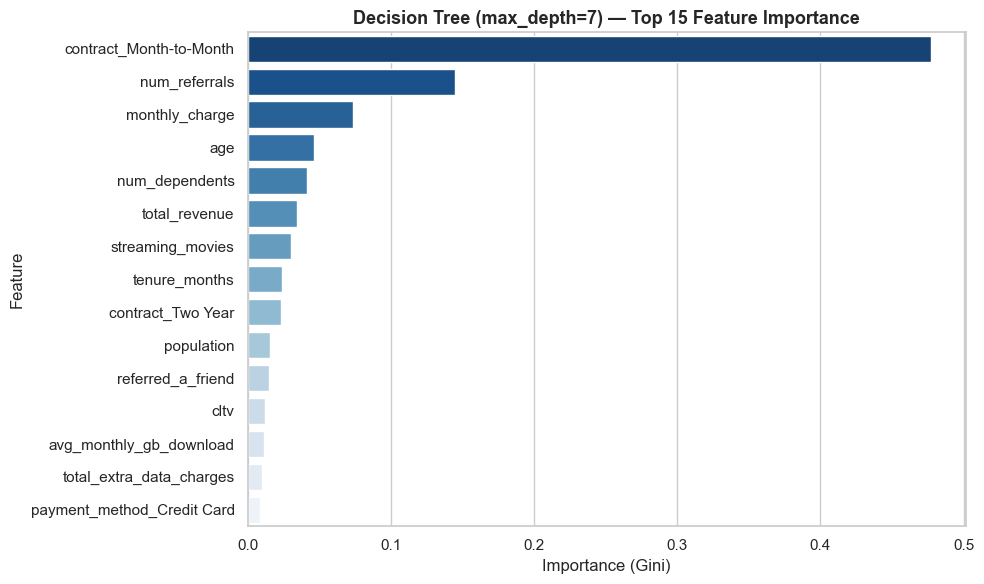

✅ Figura salvata in: c:\Users\Giada Jenny Qafalia\Desktop\develhope\Progetto_team\telco-churn-ml\outputs\figures\19_decision_tree_feature_importance.png

Top 15 feature:
                   feature  importance
   contract_Month-to-Month    0.477561
             num_referrals    0.144504
            monthly_charge    0.073308
                       age    0.046537
            num_dependents    0.041469
             total_revenue    0.034611
          streaming_movies    0.029849
             tenure_months    0.023814
         contract_Two Year    0.022846
                population    0.015488
         referred_a_friend    0.014953
                      cltv    0.012145
   avg_monthly_gb_download    0.011498
  total_extra_data_charges    0.010166
payment_method_Credit Card    0.008222


In [34]:
# Estrazione feature names dopo il preprocessing
feature_names_num = num_cols
feature_names_cat = pipeline_dt_final.named_steps["preprocessor"]\
    .named_transformers_["cat"].get_feature_names_out(cat_cols).tolist()
feature_names_bin = binary_cols

all_feature_names = feature_names_num + feature_names_cat + feature_names_bin

# Feature importance dal classificatore
importances = pipeline_dt_final.named_steps["classifier"].feature_importances_
importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature",
            palette="Blues_r", orient="h", ax=ax)
ax.set_title("Decision Tree (max_depth=7) — Top 15 Feature Importance",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance (Gini)")
ax.set_ylabel("Feature")
plt.tight_layout()

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "19_decision_tree_feature_importance.png"))
plt.savefig(figures_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Figura salvata in: {figures_path}")
print(f"\nTop 15 feature:\n{importance_df.to_string(index=False)}")

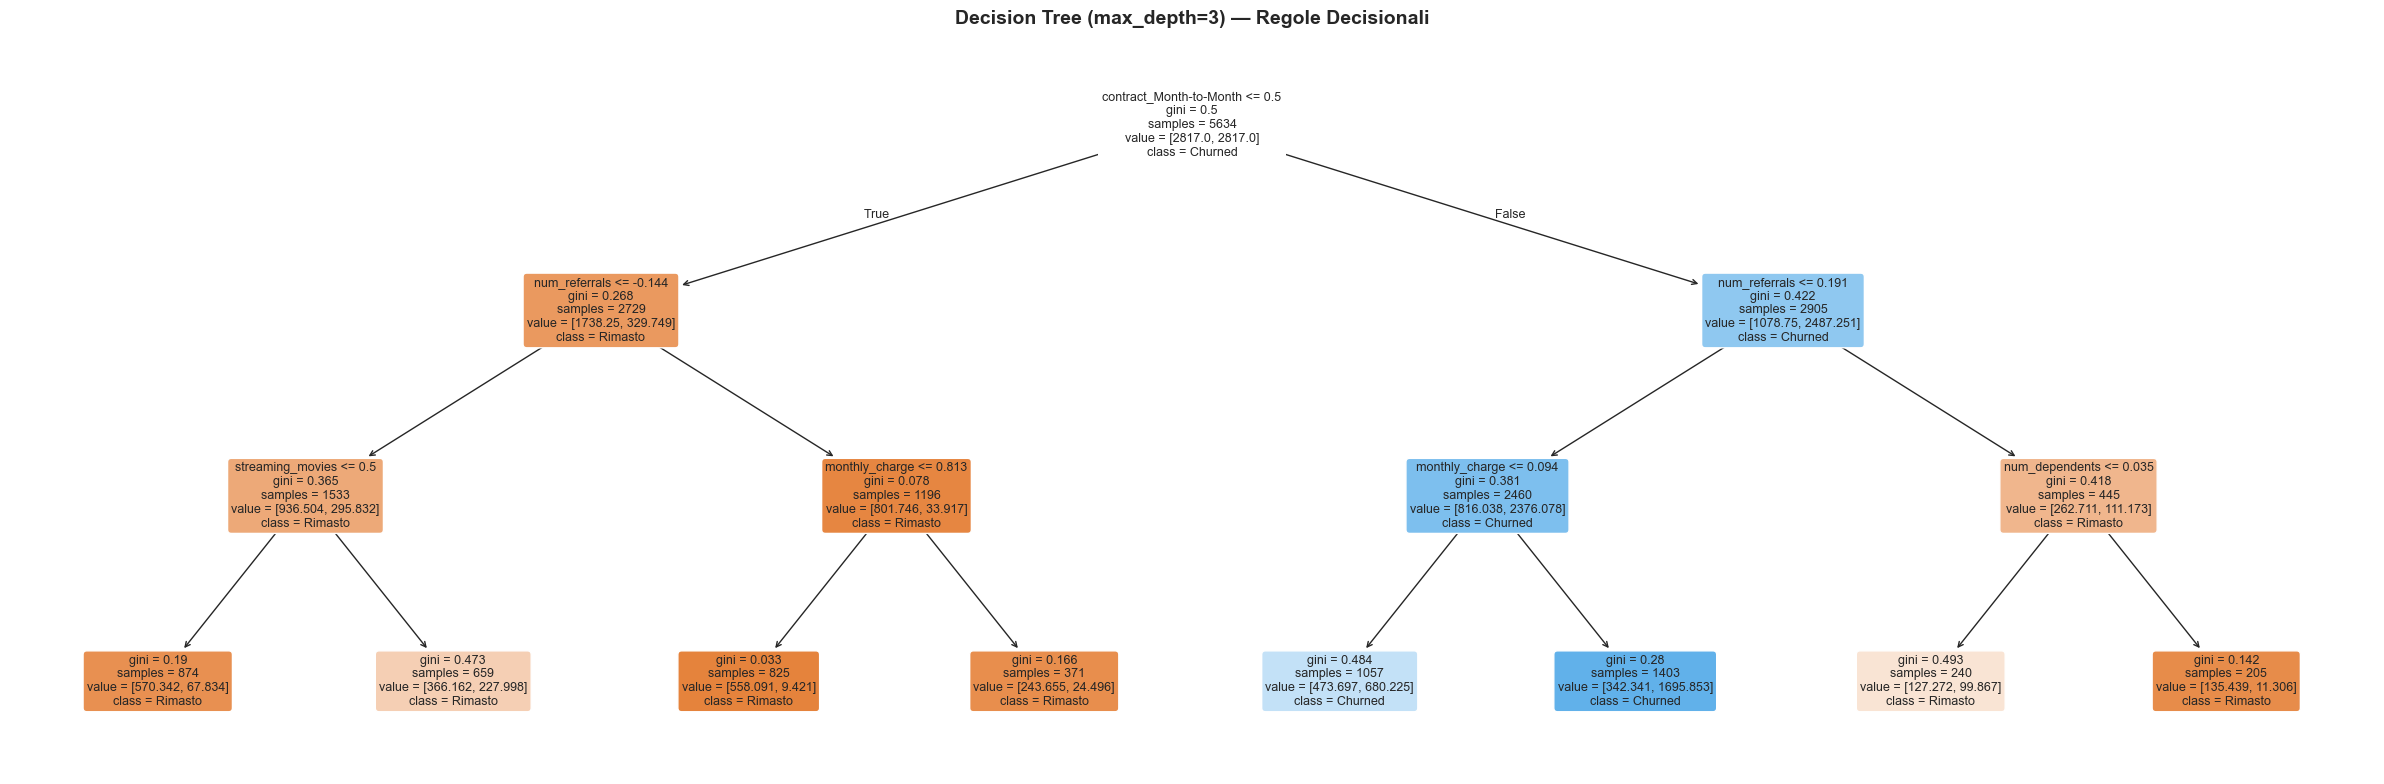

✅ Figura salvata in: c:\Users\Giada Jenny Qafalia\Desktop\develhope\Progetto_team\telco-churn-ml\outputs\figures\19_decision_tree_plot.png


In [35]:
from sklearn.tree import plot_tree

# Albero semplificato a max_depth=3 per interpretabilità
pipeline_dt_vis = Pipeline([
    ("preprocessor", build_preprocessor(num_cols, cat_cols, binary_cols)),
    ("classifier", DecisionTreeClassifier(
        max_depth=3,
        class_weight="balanced",
        random_state=42
    ))
])

pipeline_dt_vis.fit(X_train, y_train)

feature_names = pipeline_dt_vis.named_steps["preprocessor"].get_feature_names_out()
feature_names = [name.split("__")[1] for name in feature_names]

fig, ax = plt.subplots(figsize=(24, 8))
plot_tree(
    pipeline_dt_vis.named_steps["classifier"],
    feature_names=feature_names,
    class_names=["Rimasto", "Churned"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title("Decision Tree (max_depth=3) — Regole Decisionali",
             fontsize=14, fontweight="bold")
plt.tight_layout()

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "19_decision_tree_plot.png"))
plt.savefig(figures_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Figura salvata in: {figures_path}")

### Osservazioni — US-19

#### Valutazione sul Test Set (max_depth=7)

| Metrica | Rimasto (0) | Churned (1) |
|---|---|---|
| Precision | 0.93 | 0.59 |
| Recall | 0.79 | 0.84 |
| F1-Score | 0.86 | 0.70 |
| **Macro F1** | | **0.78** |

Il Decision Tree con `max_depth=7` raggiunge un **Macro F1 di 0.78**, migliorando
la Logistic Regression (0.76) pur cedendo leggermente sul Recall della classe churned
(0.84 vs 0.87). In un contesto di retention, un Recall elevato è prioritario —
un cliente a rischio non identificato rappresenta una perdita certa, mentre
un falso positivo genera al più un intervento di retention non necessario.

---

#### Feature Importance

La capacità predittiva del modello è fortemente concentrata su tre variabili:

| Feature | Importance (Gini) | Interpretazione |
|---|---|---|
| `contract_Month-to-Month` | 0.478 | Assenza di vincolo contrattuale — massima libertà di abbandono |
| `num_referrals` | 0.145 | Coinvolgimento attivo nel servizio — proxy di soddisfazione |
| `monthly_charge` | 0.073 | Sensibilità al prezzo mensile |
| `age`, `num_dependents` | 0.046, 0.041 | Profilo demografico — stabilità associata a età e nucleo familiare |

Le prime tre variabili da sole spiegano il **69%** dell'importanza complessiva del modello,
confermando la coerenza con i risultati di SelectKBest (US-17) e con l'analisi
esplorativa (US-08, US-09).

---

#### Regole Decisionali (max_depth=3)

La visualizzazione a profondità ridotta rivela la logica decisionale del modello
in forma immediatamente comunicabile:

- **Primo split**: il tipo di contratto separa il dataset in due popolazioni
  nettamente distinte — i clienti Month-to-Month presentano un profilo di rischio
  strutturalmente più elevato
- **Secondo split** (su entrambi i rami): `num_referrals` affina la segmentazione —
  anche tra i clienti Month-to-Month, chi ha portato amici mostra una propensione
  al churn significativamente inferiore
- **Terzo split**: `monthly_charge`, `streaming_movies` e `num_dependents` completano
  la profilazione, identificando segmenti ad alta purezza in entrambe le direzioni

Il Decision Tree è l'unico modello del progetto le cui regole possono essere
lette direttamente dal grafico — una proprietà di interpretabilità che nessun
altro approccio offre e che rappresenta un valore concreto per la comunicazione
con il management.